# Development 3: first VGGT-Omega forward pass

One scene, one camera, all 40 keyframes in a single forward pass. The goal is
to LOOK at what the model predicts, not to measure it. No error numbers here.

**Needs a GPU runtime.** Select Kernel > Colab > New Colab Server > a GPU
(A100 if offered, a T4 also fits: about 9 GB for 40 frames).

Two things this notebook also proves:
1. the model runs at all on Colab's NumPy 2 (unverified until now);
2. a killed session resumes: see the last section.

In [ ]:
# --- 1. Configuration ---
PERSIST_MODE = "drive"
SPLIT, BLOCK = "val", 11
LAYERS = ["camera_keyframes"]
SCENE_ID = "2025-06-13-07-09-37|78"   # urban, about 30 km/h, about 4.3 m between keyframes: real parallax
CAMERA = "front_medium"               # 1920x1200, becomes 640x400 for the model
MAX_FRAMES = None                     # None = every keyframe of the scene (40)

In [ ]:
# === CODE SYNC (auto-generated by `python -m vggt_aura.sync`, do not edit) ===
raise RuntimeError("The sync cell is empty. On your own machine, in the project folder, run:  python -m vggt_aura.sync   and reopen this notebook.")

In [3]:
# --- 3. Start the session. The GPU is checked in cell 6, only if the model actually has to run ---
from vggt_aura.session import start_session

session = start_session(persist_mode=PERSIST_MODE, require_gpu=False)

Mounted at /content/drive
installing vggt_omega
installing pybind11
installing fzi_aura
persist root: /content/drive/MyDrive/vggt-omega-aura-benchmark
data root   : /content/data/fzi-aura (runtime disk, wiped at session end)


In [4]:
# --- 4. Make sure the block is on this runtime (about 1.5 min when it is not) ---
from vggt_aura import aura_data as ad, inference as inf, geometry as geo, pins

chunks, scene_blocks, hub_files = ad.fetch_release_tables(session.data_root / "_release_tables")
BLOCK_SCENE_IDS = ad.block_scene_ids(scene_blocks, SPLIT, BLOCK)
assert SCENE_ID in BLOCK_SCENE_IDS, "SCENE_ID is not in the chosen block"
if ad.block_on_disk(session.data_root, BLOCK_SCENE_IDS, LAYERS):
    print("block already on disk")
else:
    ad.download_block(session.data_root, SPLIT, BLOCK, BLOCK_SCENE_IDS, LAYERS)

$ /usr/bin/python3 -m fzi_aura.download /content/data/fzi-aura --revision 3404bd6b8fcd6eed53a0ec7610650a6393aabb49 --splits val --scene-ids-file /content/data/fzi-aura/_scene_ids_val_block000011.txt --layers camera_keyframes --jobs 8 --verify


In [5]:
# --- 5. Pick the frames ---
import numpy as np
from fzi_aura import FZIAURADataset

dataset = FZIAURADataset(session.data_root, split=SPLIT)
scene = dataset.get_scene(SCENE_ID)
frames = inf.select_frames(scene, CAMERA, max_frames=MAX_FRAMES)
image_paths = [frame.camera_path(CAMERA) for frame in frames]
timestamps_ns = np.array([frame.timestamp_ns for frame in frames], dtype=np.int64)

print("scene:", scene.scene_id, "| camera:", CAMERA, "| frames:", len(frames))
gaps_s = np.diff(timestamps_ns) / 1e9
print("gap between frames, seconds: min %.3f | max %.3f" % (gaps_s.min(), gaps_s.max()))
gt_camera0_from_camera = inf.ground_truth_cameras(frames, CAMERA)
gt_centers = gt_camera0_from_camera[:, :3, 3]
print("ground-truth path length: %.1f m | straight-line start to end: %.1f m"
      % (np.linalg.norm(np.diff(gt_centers, axis=0), axis=1).sum(), np.linalg.norm(gt_centers[-1])))

scene: 2025-06-13-07-09-37|78 | camera: front_medium | frames: 40
gap between frames, seconds: min 0.500 | max 0.500
ground-truth path length: 166.2 m | straight-line start to end: 158.2 m


In [6]:
# --- 6. Predict, or resume: skip the model entirely if this scene was already done ---
CHECKPOINT = pins.CHECKPOINT_PUBLIC_512
RESOLUTION = inf.resolution_for(CHECKPOINT)          # tied to the checkpoint so they cannot be mixed up
STAGE = f"predict/{CAMERA}/{CHECKPOINT}"
npz_path, json_path = inf.prediction_paths(session.persist_root, scene.name, CAMERA, CHECKPOINT)

if session.manifest.is_done(SCENE_ID, STAGE) and npz_path.is_file():
    arrays, meta = inf.load_predictions(npz_path, json_path)
    print("RESUMED: predictions loaded from", npz_path)
    print("         made", meta.get("created_utc"), "on", meta.get("gpu"), "- the model was not loaded")
else:
    import time, torch
    from datetime import datetime, timezone

    if not torch.cuda.is_available():
        raise RuntimeError("This scene is not predicted yet and the model needs a GPU. Connect to a GPU server and re-run.")

    started = time.time()
    checkpoint_path = inf.download_checkpoint(CHECKPOINT, "/content/checkpoints")
    print(f"checkpoint ready in {time.time() - started:.0f} s:", checkpoint_path)
    model = inf.load_model(checkpoint_path)
    arrays = inf.run_model(model, image_paths, RESOLUTION)
    arrays["gt_camera0_from_camera"] = gt_camera0_from_camera
    arrays["timestamps_ns"] = timestamps_ns
    meta = {
        "scene_id": SCENE_ID, "scene_name": scene.name, "camera": CAMERA, "frames": len(frames),
        "checkpoint": CHECKPOINT, "image_resolution": RESOLUTION, "input_hw": arrays["input_hw"].tolist(),
        "dataset_revision": pins.AURA_DATASET_REVISION, "model_code_commit": pins.VGGT_OMEGA_COMMIT,
        "model_weights_revision": pins.VGGT_OMEGA_HF_REVISION,
        "gpu": torch.cuda.get_device_name(0), "torch": torch.__version__, "numpy": np.__version__,
        "forward_seconds": round(arrays["seconds"], 2), "peak_gpu_gb": round(arrays["peak_gpu_gb"], 2),
        "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "image_files": [p.name for p in image_paths],
    }
    size_mb = inf.save_predictions(npz_path, json_path, arrays, meta)
    session.manifest.mark_done(SCENE_ID, STAGE, file=str(npz_path.relative_to(session.persist_root)))
    print(f"forward pass: {meta['forward_seconds']} s for {len(frames)} frames | peak GPU {meta['peak_gpu_gb']} GB | {meta['gpu']}")
    print(f"saved {size_mb:.1f} MB ->", npz_path)
    del model
    torch.cuda.empty_cache()

RESUMED: predictions loaded from /content/drive/MyDrive/vggt-omega-aura-benchmark/predictions/vggt_omega_1b_512/2025-06-13-07-09-37_78/front_medium.npz
         made 2026-09-18T10:05:39+00:00 on NVIDIA A100-SXM4-40GB - the model was not loaded


In [7]:
# --- 7. Look at the numbers (no error metrics yet) ---
depth, conf = arrays["depth"], arrays["depth_conf"]
extrinsics, intrinsics = arrays["extrinsics"], arrays["intrinsics"]
height, width = (int(v) for v in arrays["input_hw"])
print("model input size (W x H):", width, "x", height, "| depth", depth.shape, "| conf", conf.shape)
print("any NaN or inf in depth:", bool(~np.isfinite(depth).all()), "| depth > 0 everywhere:", bool((depth > 0).all()))
print()
print("depth, in the model's own units (NOT metres): min %.3f | median %.3f | max %.3f" % (depth.min(), np.median(depth), depth.max()))
print("confidence:                                    min %.2f | median %.2f | max %.2f" % (conf.min(), np.median(conf), conf.max()))
print()

calibration = scene.calibration()
P = calibration.camera_projection_matrix(CAMERA)
entry = calibration.sensor(f"camera/{CAMERA}")["intrinsics"]
gt_fx, gt_fy, gt_cx, gt_cy = geo.scale_intrinsics(P[0, 0], P[1, 1], P[0, 2], P[1, 2],
                                                  (entry["width"], entry["height"]), (width, height))
print("focal lengths in model-input pixels     fx       fy")
print("  ground truth (calibration, scaled)  %7.1f  %7.1f   -> field of view %.1f x %.1f deg"
      % (gt_fx, gt_fy, geo.fov_degrees(gt_fx, width), geo.fov_degrees(gt_fy, height)))
print("  predicted, median over frames       %7.1f  %7.1f   -> field of view %.1f x %.1f deg"
      % (np.median(intrinsics[:, 0, 0]), np.median(intrinsics[:, 1, 1]),
         geo.fov_degrees(np.median(intrinsics[:, 0, 0]), width), geo.fov_degrees(np.median(intrinsics[:, 1, 1]), height)))
print("  predicted fx across frames: min %.1f max %.1f (one physical camera, so ideally constant)"
      % (intrinsics[:, 0, 0].min(), intrinsics[:, 0, 0].max()))
print("  true principal point %.1f, %.1f | the model always assumes the centre %.1f, %.1f" % (gt_cx, gt_cy, width / 2, height / 2))
print()
print("first predicted extrinsic (should be close to identity: the first camera IS the world):")
print(np.round(extrinsics[0], 4))

model input size (W x H): 640 x 400 | depth (40, 400, 640) | conf (40, 400, 640)
any NaN or inf in depth: False | depth > 0 everywhere: True

depth, in the model's own units (NOT metres): min 0.038 | median 0.186 | max 5.340
confidence:                                    min 1.00 | median 9.98 | max 83.94

focal lengths in model-input pixels     fx       fy
  ground truth (calibration, scaled)    538.2    564.7   -> field of view 61.5 x 39.0 deg
  predicted, median over frames         496.9    497.7   -> field of view 65.6 x 43.8 deg
  predicted fx across frames: min 487.0 max 509.6 (one physical camera, so ideally constant)
  true principal point 324.8, 196.3 | the model always assumes the centre 320.0, 200.0

first predicted extrinsic (should be close to identity: the first camera IS the world):
[[ 1.e+00  3.e-04 -2.e-04 -2.e-04]
 [-3.e-04  1.e+00 -5.e-04  2.e-04]
 [ 2.e-04  5.e-04  1.e+00 -5.e-04]]


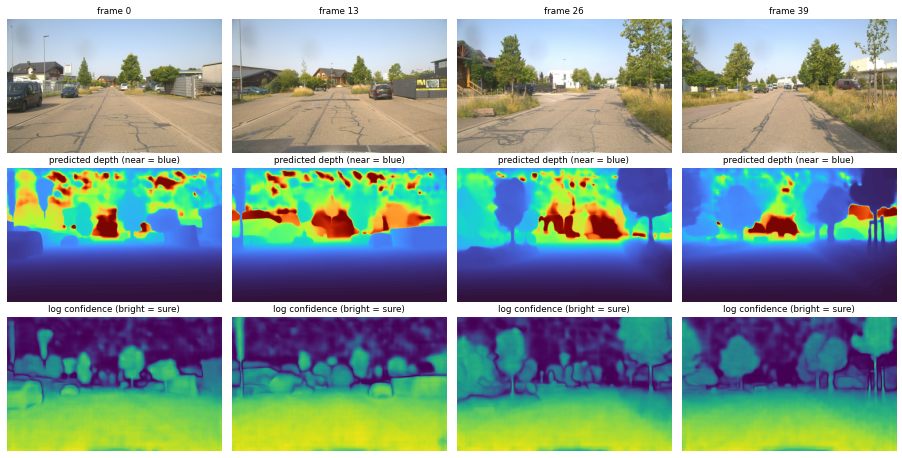

In [8]:
# --- 8. Look at the depth maps ---
import matplotlib.pyplot as plt
from PIL import Image

show = np.linspace(0, len(frames) - 1, 4).round().astype(int)
figure, axes = plt.subplots(3, 4, figsize=(13, 6.6), dpi=70)
for column, index in enumerate(show):
    image = np.asarray(Image.open(image_paths[index]).convert("RGB").resize((width, height)))
    axes[0, column].imshow(image)
    axes[0, column].set_title(f"frame {index}", fontsize=9)
    low, high = np.percentile(depth[index], [2, 98])
    axes[1, column].imshow(depth[index], cmap="turbo", vmin=low, vmax=high)
    axes[1, column].set_title("predicted depth (near = blue)", fontsize=9)
    axes[2, column].imshow(np.log(conf[index]), cmap="viridis")
    axes[2, column].set_title("log confidence (bright = sure)", fontsize=9)
for axis in axes.ravel():
    axis.axis("off")
figure.tight_layout()
figure_dir = session.persist_root / "figures" / "phase3"
figure_dir.mkdir(parents=True, exist_ok=True)
figure.savefig(figure_dir / f"{scene.name}_{CAMERA}_depth.png", dpi=70)
plt.show()

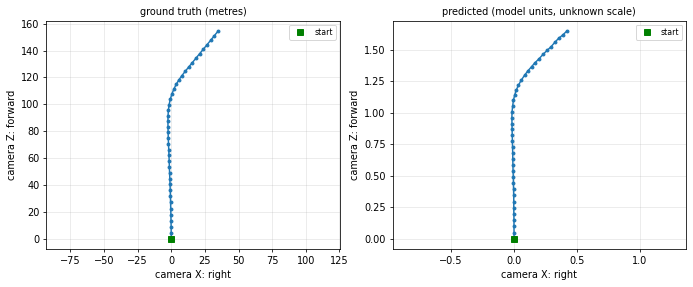

path length: ground truth 166.2 m | predicted 1.805 model units
implied metres per model unit, from path length alone: 92.08
median predicted depth x that factor = 17.1 m (a plausible street-scene depth would be roughly 10 to 30 m)


In [9]:
# --- 9. Look at the camera path, from above. Two separate panels: the units differ ---
# Camera position in the world is -R.T @ t, not t (see vggt_aura/geometry.py).
predicted_centers = geo.camera_centers(extrinsics)
figure, axes = plt.subplots(1, 2, figsize=(10, 4.2), dpi=70)
for axis, centers, title in ((axes[0], gt_centers, "ground truth (metres)"),
                             (axes[1], predicted_centers, "predicted (model units, unknown scale)")):
    axis.plot(centers[:, 0], centers[:, 2], "-o", markersize=3)
    axis.plot(centers[0, 0], centers[0, 2], "gs", label="start")
    axis.set_xlabel("camera X: right"); axis.set_ylabel("camera Z: forward")
    axis.set_title(title, fontsize=10); axis.axis("equal"); axis.grid(alpha=0.3); axis.legend(fontsize=8)
figure.tight_layout()
figure.savefig(figure_dir / f"{scene.name}_{CAMERA}_path.png", dpi=70)
plt.show()

gt_length = np.linalg.norm(np.diff(gt_centers, axis=0), axis=1).sum()
predicted_length = np.linalg.norm(np.diff(predicted_centers, axis=0), axis=1).sum()
print("path length: ground truth %.1f m | predicted %.3f model units" % (gt_length, predicted_length))
print("implied metres per model unit, from path length alone: %.2f" % (gt_length / predicted_length))
print("median predicted depth x that factor = %.1f m (a plausible street-scene depth would be roughly 10 to 30 m)"
      % (np.median(depth) * gt_length / predicted_length))

## Resume test (do this once)

1. Run the whole notebook. Cell 6 runs the model and prints `saved ... MB`.
2. Kill the runtime: command palette > `Colab: Remove Server`.
3. Connect to a NEW server and run the whole notebook again. A CPU server is enough
   and costs far less: a resumed run never touches the model.
4. Cell 6 must now print `RESUMED: predictions loaded from ...` and must NOT
   download the checkpoint or load the model. Cells 7 to 9 must show the same
   numbers and pictures as before.

If step 4 behaves like that, resuming works: the manifest and the predictions
survived on Drive while everything on the runtime disk was wiped.